<a href="https://colab.research.google.com/github/destiny424/hasts211_assignment-1/blob/main/R2420862_Econometrics_Assigmnent_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# FINANCIAL ECONOMETRICS - Project #1
# Best-Practices Handbook: Time Series Modeling Challenges
# ============================================================
# Topics Covered:
#   1. Multicollinearity
#   2. Skewness
#   3. Sensitivity to Outliers
#   4. Lack of Interpretation
# ============================================================

# --- Install / Import Libraries ---
!pip install yfinance arch statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
print("✅ Libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 4.2 MB/s eta 0:00:00
✅ Libraries loaded successfully.


In [ ]:
# ============================================================
# DATA: AAPL + correlated tech stocks from Yahoo Finance
# Date range: 2018 - 2023
# ============================================================

# AAPL is our primary asset
# MSFT, GOOG, META, NVDA are used to demonstrate multicollinearity
# (highly correlated tech stocks — realistic quant scenario)

tickers = ['AAPL', 'MSFT', 'GOOG', 'META', 'NVDA']

raw = yf.download(tickers, start='2018-01-01', end='2023-12-31')['Close']
raw.dropna(inplace=True)

# Daily log returns
returns = np.log(raw / raw.shift(1)).dropna()

# AAPL returns separately for single-asset analysis
aapl_returns = returns['AAPL']

print("✅ Data downloaded successfully.")
print(f"   Period : 2018-01-01 to 2023-12-31")
print(f"   Tickers: {list(raw.columns)}")
print(f"   Shape  : {returns.shape}")
print()
print(returns.tail())

[*********************100%***********************]  5 of 5 completed

✅ Data downloaded successfully.
   Period : 2018-01-01 to 2023-12-31
   Tickers: ['AAPL', 'GOOG', 'META', 'MSFT', 'NVDA']
   Shape  : (1508, 5)

Ticker          AAPL      GOOG      META      MSFT      NVDA
Date                                                        
2023-12-22 -0.005563  0.006467 -0.001979  0.002780 -0.003271
2023-12-26 -0.002845  0.000701  0.004067  0.000214  0.009153
2023-12-27  0.000518 -0.009710  0.008419 -0.001576  0.002796
2023-12-28  0.002224 -0.001132  0.001368  0.003230  0.002123
2023-12-29 -0.005439 -0.002480 -0.012243  0.002023  0.000000


In [ ]:
# ============================================================
# TOPIC 1: MULTICOLLINEARITY
# ============================================================

markdown_text = """
DEFINITION
----------
Multicollinearity occurs when two or more predictor variables in a regression
model are highly linearly correlated. Formally, for predictors X1, X2, ..., Xk,
multicollinearity exists when:

    Xi ≈ α0 + α1*X1 + ... + αk*Xk   for some i

This is measured using the Variance Inflation Factor (VIF):

    VIF(j) = 1 / (1 - R²j)

Where R²j is the R-squared from regressing predictor Xj on all other predictors.
A VIF > 5 indicates moderate multicollinearity; VIF > 10 is severe.

DESCRIPTION
-----------
Multicollinearity arises when predictor variables in a model move together so
closely that the model cannot distinguish their individual effects on the outcome.
In volatility modeling, this commonly occurs when using multiple correlated asset
returns (e.g., tech stocks) as factors — making coefficient estimates unstable
and unreliable.
"""
print(markdown_text)


DEFINITION
----------
Multicollinearity occurs when two or more predictor variables in a regression
model are highly linearly correlated. Formally, for predictors X1, X2, ..., Xk,
multicollinearity exists when:

    Xi ≈ α0 + α1*X1 + ... + αk*Xk   for some i

This is measured using the Variance Inflation Factor (VIF):

    VIF(j) = 1 / (1 - R²j)

Where R²j is the R-squared from regressing predictor Xj on all other predictors.
A VIF > 5 indicates moderate multicollinearity; VIF > 10 is severe.

DESCRIPTION
-----------
Multicollinearity arises when predictor variables in a model move together so
closely that the model cannot distinguish their individual effects on the outcome.
In volatility modeling, this commonly occurs when using multiple correlated asset
returns (e.g., tech stocks) as factors — making coefficient estimates unstable
and unreliable.



In [ ]:
# ============================================================
# TOPIC 1: DEMONSTRATION — VIF on AAPL, MSFT, GOOG, META, NVDA
# ============================================================

# Use returns of all 5 stocks as predictors
X = returns.copy()
X = sm.add_constant(X)  # Add intercept

# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data['Ticker'] = returns.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i+1)  # +1 to skip constant
    for i in range(len(returns.columns))
]

print("=" * 40)
print("   VARIANCE INFLATION FACTORS (VIF)")
print("=" * 40)
print(vif_data.to_string(index=False))
print()
print("Interpretation:")
print("  VIF = 1       → No multicollinearity")
print("  VIF = 1–5     → Moderate (acceptable)")
print("  VIF = 5–10    → High (concerning)")
print("  VIF > 10      → Severe multicollinearity")

   VARIANCE INFLATION FACTORS (VIF)
Ticker      VIF
  AAPL 2.578599
  GOOG 2.945106
  META 1.899413
  MSFT 3.536466
  NVDA 2.166681

Interpretation:
  VIF = 1       → No multicollinearity
  VIF = 1–5     → Moderate (acceptable)
  VIF = 5–10    → High (concerning)
  VIF > 10      → Severe multicollinearity


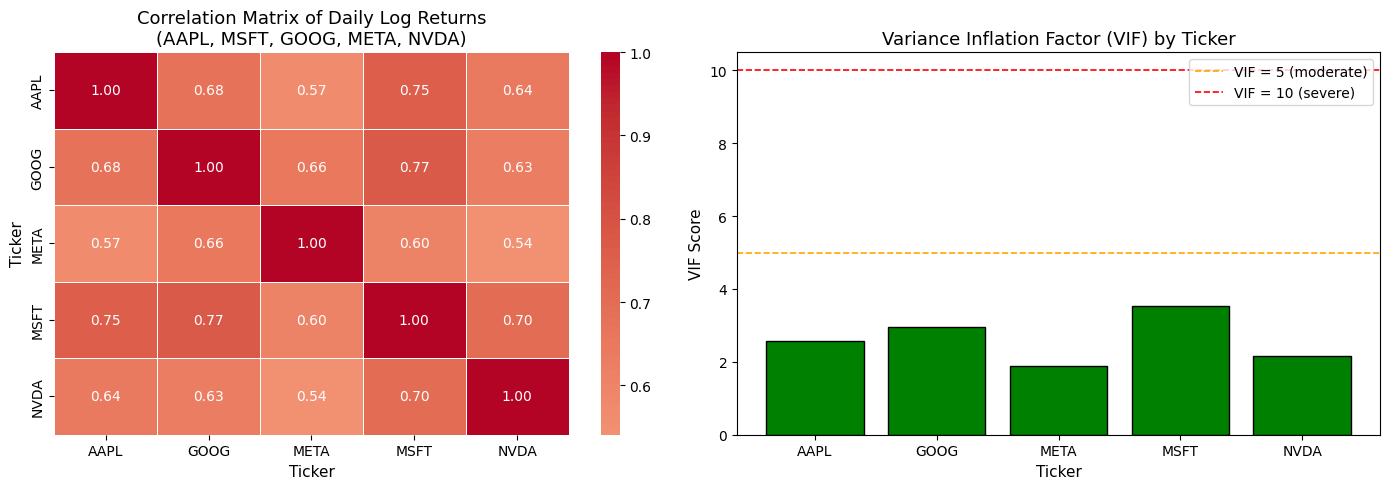

✅ Diagram saved.


In [ ]:
# ============================================================
# TOPIC 1: DIAGRAM — Correlation Heatmap of Log Returns
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Correlation Heatmap ---
corr_matrix = returns.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix of Daily Log Returns\n(AAPL, MSFT, GOOG, META, NVDA)')

# --- Plot 2: VIF Bar Chart ---
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red'
          for v in vif_data['VIF']]
axes[1].bar(vif_data['Ticker'], vif_data['VIF'], color=colors, edgecolor='black')
axes[1].axhline(y=5,  color='orange', linestyle='--', linewidth=1.2, label='VIF = 5 (moderate)')
axes[1].axhline(y=10, color='red',    linestyle='--', linewidth=1.2, label='VIF = 10 (severe)')
axes[1].set_title('Variance Inflation Factor (VIF) by Ticker')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('VIF Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('multicollinearity_diagram.png', dpi=150)
plt.show()
print("✅ Diagram saved.")

In [ ]:
# ============================================================
# TOPIC 1: DIAGNOSIS, DAMAGE & DIRECTIONS
# ============================================================

summary = """
DIAGNOSIS
---------
Three methods to detect multicollinearity:
  1. Correlation Matrix  → Pairwise correlations > 0.80 are a warning sign
  2. VIF                 → VIF > 5 (moderate), VIF > 10 (severe)
  3. Condition Number    → Values > 30 suggest strong multicollinearity

Condition Number Test:
"""
print(summary)

# Condition Number
eigenvalues = np.linalg.eigvals(returns.corr().values)
condition_number = np.sqrt(max(eigenvalues) / min(eigenvalues))
print(f"  Condition Number = {condition_number:.2f}")
if condition_number > 30:
    print("  ⚠️  SEVERE multicollinearity detected (CN > 30)")
elif condition_number > 10:
    print("  ⚠️  MODERATE multicollinearity detected (CN > 10)")
else:
    print("  ✅  No serious multicollinearity (CN < 10)")

damage = """
DAMAGE
------
Multicollinearity causes the following problems in volatility models:
  • Inflated standard errors → coefficient estimates become unstable
  • Unreliable t-statistics → wrong conclusions about factor significance
  • Overstated R² → model appears to fit well but predictions are poor
  • Signs of coefficients may flip with small data changes
  • Makes hedging decisions unreliable on the derivatives desk

DIRECTIONS (How to Fix It)
--------------------------
  1. Principal Component Analysis (PCA)
       → Transforms correlated factors into uncorrelated components
  2. Ridge Regression (L2 Regularization)
       → Penalizes large coefficients, stabilizes estimates under collinearity
  3. Partial Least Squares (PLS)
       → Reduces dimensions while retaining predictive power
  4. Variable Selection
       → Drop one of two highly correlated predictors (keep VIF < 5)
  5. Factor Models (e.g., Fama-French)
       → Use orthogonal factors by construction

References:
  - Greene, W. H. (2012). Econometric Analysis (7th ed.). Pearson.
  - Brooks, C. (2019). Introductory Econometrics for Finance. Cambridge.
"""
print(damage)


DIAGNOSIS
---------
Three methods to detect multicollinearity:
  1. Correlation Matrix  → Pairwise correlations > 0.80 are a warning sign
  2. VIF                 → VIF > 5 (moderate), VIF > 10 (severe)
  3. Condition Number    → Values > 30 suggest strong multicollinearity

Condition Number Test:

  Condition Number = 4.20
  ✅  No serious multicollinearity (CN < 10)

DAMAGE
------
Multicollinearity causes the following problems in volatility models:
  • Inflated standard errors → coefficient estimates become unstable
  • Unreliable t-statistics → wrong conclusions about factor significance
  • Overstated R² → model appears to fit well but predictions are poor
  • Signs of coefficients may flip with small data changes
  • Makes hedging decisions unreliable on the derivatives desk

DIRECTIONS (How to Fix It)
--------------------------
  1. Principal Component Analysis (PCA)
       → Transforms correlated factors into uncorrelated components
  2. Ridge Regression (L2 Regularization)
   

# ============================================================
# TOPIC 2: SKEWNESS
# ============================================================

markdown_text = """
DEFINITION
----------
Skewness measures the asymmetry of a probability distribution around its mean.
For a return series r with T observations, skewness is defined as:

    Skewness = (1/T) * Σ[(rt - μ)³] / σ³

Where:
    μ  = mean of returns
    σ  = standard deviation of returns
    T  = number of observations

Interpretation:
    Skewness = 0   → Perfectly symmetric (Normal distribution)
    Skewness < 0   → Left/Negative skew (fat left tail — more extreme losses)
    Skewness > 0   → Right/Positive skew (fat right tail — more extreme gains)

For financial returns, negative skewness is most common and most dangerous,
as it implies a higher probability of large losses than a normal distribution
would suggest.

DESCRIPTION
-----------
Skewness describes how asymmetric the distribution of asset returns is relative
to the normal distribution. In volatility modeling, ignoring skewness leads to
systematic mispricing of options — particularly out-of-the-money puts — because
models that assume normality underestimate the probability of large downside moves.
"""
print(markdown_text)

In [ ]:
# ============================================================
# TOPIC 2: DEMONSTRATION — Skewness of AAPL Returns
# ============================================================

from scipy.stats import skew, kurtosis, jarque_bera

# Focus on AAPL returns
r = aapl_returns.copy()

# --- Descriptive Statistics ---
mean_r   = r.mean()
std_r    = r.std()
skew_r   = skew(r)
kurt_r   = kurtosis(r)  # Excess kurtosis (normal = 0)
jb_stat, jb_pval = jarque_bera(r)

print("=" * 50)
print("   AAPL DAILY LOG RETURNS — DISTRIBUTION STATS")
print("=" * 50)
print(f"   Mean              : {mean_r:.6f}")
print(f"   Std Deviation     : {std_r:.6f}")
print(f"   Skewness          : {skew_r:.4f}")
print(f"   Excess Kurtosis   : {kurt_r:.4f}")
print(f"   Jarque-Bera Stat  : {jb_stat:.4f}")
print(f"   Jarque-Bera p-val : {jb_pval:.6f}")
print("=" * 50)
print()

if skew_r < -0.5:
    print(f"  ⚠️  Significant NEGATIVE skew ({skew_r:.4f})")
    print("      → Left tail is fatter than right tail")
    print("      → More extreme losses than a normal dist predicts")
elif skew_r > 0.5:
    print(f"  ⚠️  Significant POSITIVE skew ({skew_r:.4f})")
    print("      → Right tail is fatter than left tail")
else:
    print(f"  ℹ️  Mild skewness ({skew_r:.4f}) — relatively symmetric")

print()
if jb_pval < 0.05:
    print("  ✅ Jarque-Bera test: REJECT normality (p < 0.05)")
    print("     → Returns are NOT normally distributed")
else:
    print("  ℹ️  Jarque-Bera test: Cannot reject normality")

   AAPL DAILY LOG RETURNS — DISTRIBUTION STATS
   Mean              : 0.001030
   Std Deviation     : 0.019965
   Skewness          : -0.2444
   Excess Kurtosis   : 5.0591
   Jarque-Bera Stat  : 1623.1775
   Jarque-Bera p-val : 0.000000

  ℹ️  Mild skewness (-0.2444) — relatively symmetric

  ✅ Jarque-Bera test: REJECT normality (p < 0.05)
     → Returns are NOT normally distributed


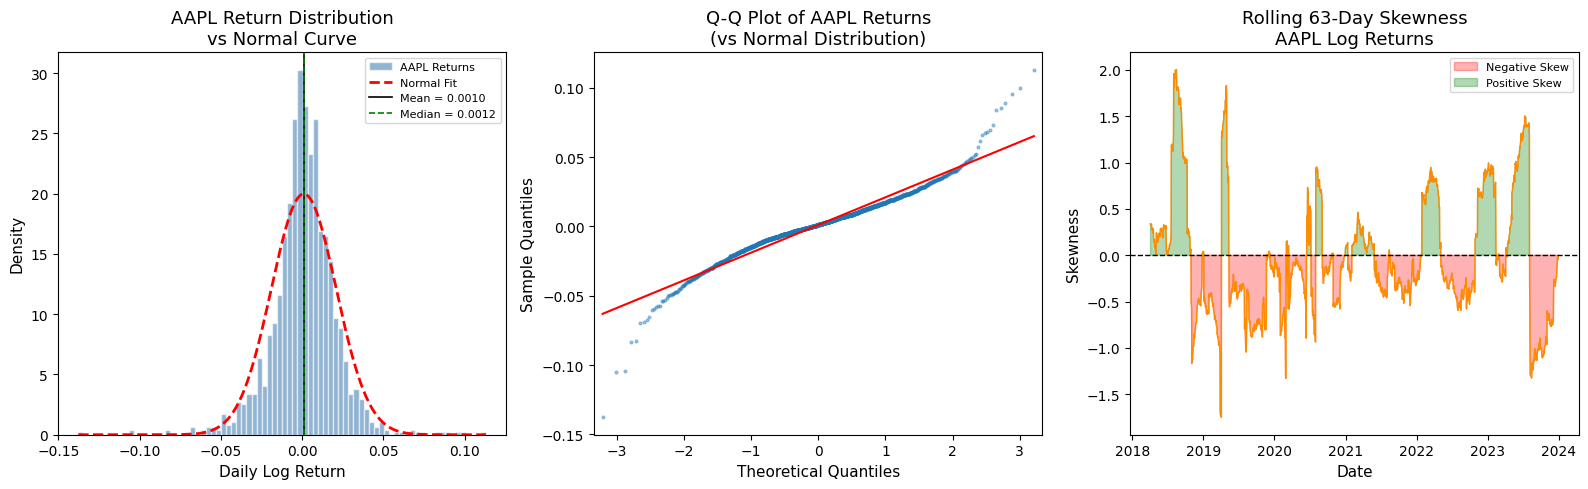

✅ Diagram saved.


In [ ]:
# ============================================================
# TOPIC 2: DIAGRAM — Skewness Visualization of AAPL Returns
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Histogram vs Normal Curve ---
x_range = np.linspace(r.min(), r.max(), 300)
normal_pdf = stats.norm.pdf(x_range, mean_r, std_r)

axes[0].hist(r, bins=80, density=True, color='steelblue',
             alpha=0.6, edgecolor='white', label='AAPL Returns')
axes[0].plot(x_range, normal_pdf, 'r--', linewidth=2, label='Normal Fit')
axes[0].axvline(mean_r, color='black', linestyle='-',  linewidth=1.2, label=f'Mean = {mean_r:.4f}')
axes[0].axvline(r.median(), color='green', linestyle='--', linewidth=1.2, label=f'Median = {r.median():.4f}')
axes[0].set_title('AAPL Return Distribution\nvs Normal Curve')
axes[0].set_xlabel('Daily Log Return')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# --- Plot 2: QQ Plot ---
sm.qqplot(r, line='s', ax=axes[1], alpha=0.4, markersize=2)
axes[1].set_title('Q-Q Plot of AAPL Returns\n(vs Normal Distribution)')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

# --- Plot 3: Rolling Skewness over time ---
rolling_skew = r.rolling(window=63).skew()  # ~1 quarter rolling window
axes[2].plot(rolling_skew.index, rolling_skew, color='darkorange', linewidth=1)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].fill_between(rolling_skew.index, rolling_skew, 0,
                     where=(rolling_skew < 0), alpha=0.3,
                     color='red', label='Negative Skew')
axes[2].fill_between(rolling_skew.index, rolling_skew, 0,
                     where=(rolling_skew > 0), alpha=0.3,
                     color='green', label='Positive Skew')
axes[2].set_title('Rolling 63-Day Skewness\nAAPL Log Returns')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Skewness')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('skewness_diagram.png', dpi=150)
plt.show()
print("✅ Diagram saved.")

In [ ]:
# ============================================================
# TOPIC 2: DIAGNOSIS, DAMAGE & DIRECTIONS
# ============================================================

summary = """
DIAGNOSIS
---------
Three methods to detect skewness in return series:

  1. Sample Skewness Coefficient
       → Compute directly: Skewness = E[(r - μ)³] / σ³
       → |Skewness| > 0.5 is considered meaningful

  2. Jarque-Bera Test
       → Tests joint normality using skewness and kurtosis:
          JB = (T/6) * [S² + (K²/4)]
       → p-value < 0.05 → reject normality → skewness likely present

  3. Q-Q Plot (Quantile-Quantile)
       → Points deviating from the 45° line at the tails signal skewness
       → S-shaped curve = skewness; U-shaped tails = kurtosis
"""
print(summary)

# Print skewness for all tickers
print("  Skewness across all tickers:")
print("  " + "-"*35)
for col in returns.columns:
    s = skew(returns[col])
    flag = "⚠️ " if abs(s) > 0.5 else "✅ "
    print(f"  {flag} {col}: {s:.4f}")

damage = """

DAMAGE
------
Ignoring skewness in volatility modeling causes:
  • Mispriced options → OTM puts underpriced, exposing the desk to losses
  • Underestimated Value-at-Risk (VaR) → risk limits set too loosely
  • Poor hedge ratios → delta/gamma hedges calibrated on wrong distribution
  • Model risk → Black-Scholes assumes normality, breaks down under skew
  • Regulatory capital underestimation → Basel III violations possible

DIRECTIONS (How to Fix It)
--------------------------
  1. Skewed-t Distribution (Hansen, 1994)
       → Explicitly models asymmetry + fat tails in return distribution
  2. Gram-Charlier Expansion
       → Adjusts normal distribution using skewness and kurtosis corrections
  3. GARCH with Skewed Innovations
       → Use skewed-t or GED error distributions in GARCH models
  4. Jump-Diffusion Models (Merton, 1976)
       → Adds a jump component to capture sudden large negative moves
  5. Cornish-Fisher VaR Adjustment
       → Corrects VaR estimates using sample skewness and kurtosis

References:
  - Hansen, B. E. (1994). Autoregressive Conditional Density Estimation.
    International Economic Review, 35(3), 705–730.
  - Hull, J. C. (2018). Options, Futures, and Other Derivatives (10th ed.).
    Pearson.
"""
print(damage)


DIAGNOSIS
---------
Three methods to detect skewness in return series:

  1. Sample Skewness Coefficient
       → Compute directly: Skewness = E[(r - μ)³] / σ³
       → |Skewness| > 0.5 is considered meaningful

  2. Jarque-Bera Test
       → Tests joint normality using skewness and kurtosis:
          JB = (T/6) * [S² + (K²/4)]
       → p-value < 0.05 → reject normality → skewness likely present

  3. Q-Q Plot (Quantile-Quantile)
       → Points deviating from the 45° line at the tails signal skewness
       → S-shaped curve = skewness; U-shaped tails = kurtosis

  Skewness across all tickers:
  -----------------------------------
  ✅  AAPL: -0.2444
  ✅  GOOG: -0.2451
  ⚠️  META: -1.5857
  ✅  MSFT: -0.2343
  ✅  NVDA: -0.2042


DAMAGE
------
Ignoring skewness in volatility modeling causes:
  • Mispriced options → OTM puts underpriced, exposing the desk to losses
  • Underestimated Value-at-Risk (VaR) → risk limits set too loosely
  • Poor hedge ratios → delta/gamma hedges calibrated o

In [ ]:
# ============================================================
# TOPIC 3: SENSITIVITY TO OUTLIERS
# ============================================================

markdown_text = """
DEFINITION
----------
An outlier is an observation that lies an abnormal distance from other values
in the dataset. In a return series rt, an observation is flagged as an outlier if:

    |rt - μ| > k * σ

Where:
    μ  = mean of returns
    σ  = standard deviation of returns
    k  = threshold multiplier (commonly k = 3 for financial data)

A model is said to be sensitive to outliers if its parameter estimates change
significantly when outliers are included vs excluded. This is measured by:

    Influence = |θ_full - θ_reduced| / SE(θ_full)

Where θ_full uses all data and θ_reduced drops the outlier observations.

Cook's Distance is another common measure:
    Di = (ei²/ p*MSE) * (hii / (1 - hii)²)

Where hii is the leverage of observation i, ei is the residual,
p is the number of parameters, and MSE is mean squared error.

DESCRIPTION
-----------
Sensitivity to outliers refers to the degree to which extreme observations
disproportionately influence a model's parameter estimates and predictions.
In financial time series, outliers often correspond to real market events
(crashes, earnings shocks, flash crashes) and ignoring them — or over-weighting
them — leads to models that perform poorly in both normal and stressed markets.
"""
print(markdown_text)


DEFINITION
----------
An outlier is an observation that lies an abnormal distance from other values
in the dataset. In a return series rt, an observation is flagged as an outlier if:

    |rt - μ| > k * σ

Where:
    μ  = mean of returns
    σ  = standard deviation of returns
    k  = threshold multiplier (commonly k = 3 for financial data)

A model is said to be sensitive to outliers if its parameter estimates change
significantly when outliers are included vs excluded. This is measured by:

    Influence = |θ_full - θ_reduced| / SE(θ_full)

Where θ_full uses all data and θ_reduced drops the outlier observations.

Cook's Distance is another common measure:
    Di = (ei²/ p*MSE) * (hii / (1 - hii)²)

Where hii is the leverage of observation i, ei is the residual,
p is the number of parameters, and MSE is mean squared error.

DESCRIPTION
-----------
Sensitivity to outliers refers to the degree to which extreme observations
disproportionately influence a model's parameter estimates and 

In [ ]:
# ============================================================
# TOPIC 3: DEMONSTRATION — Impact of Outliers on OLS Regression
# ============================================================

# We regress AAPL returns on MSFT returns (simple factor model)
# Then show how outliers distort the regression line

y = returns['AAPL'].values
X_raw = returns['MSFT'].values
X_ols = sm.add_constant(X_raw)

# --- Full model (with outliers) ---
model_full = sm.OLS(y, X_ols).fit()

# --- Identify outliers using 3-sigma rule ---
residuals   = model_full.resid
std_resid   = residuals.std()
outlier_mask = np.abs(residuals) > 3 * std_resid
n_outliers  = outlier_mask.sum()

# --- Reduced model (outliers removed) ---
model_clean = sm.OLS(y[~outlier_mask],
                     X_ols[~outlier_mask]).fit()

print("=" * 55)
print("   OLS REGRESSION: AAPL ~ MSFT Returns")
print("=" * 55)
print(f"   Total observations     : {len(y)}")
print(f"   Outliers detected (3σ) : {n_outliers}")
print(f"   Clean observations     : {len(y) - n_outliers}")
print()
print(f"{'Parameter':<20} {'Full Model':>15} {'Clean Model':>15} {'Change':>10}")
print("-" * 62)
print(f"{'Intercept (α)':<20} {model_full.params[0]:>15.6f} "
      f"{model_clean.params[0]:>15.6f} "
      f"{abs(model_full.params[0]-model_clean.params[0]):>10.6f}")
print(f"{'Beta (β)':<20} {model_full.params[1]:>15.6f} "
      f"{model_clean.params[1]:>15.6f} "
      f"{abs(model_full.params[1]-model_clean.params[1]):>10.6f}")
print(f"{'R-squared':<20} {model_full.rsquared:>15.6f} "
      f"{model_clean.rsquared:>15.6f} "
      f"{abs(model_full.rsquared-model_clean.rsquared):>10.6f}")
print("-" * 62)
print()
print("  Outlier dates (AAPL):")
outlier_dates = returns.index[outlier_mask]
for d in outlier_dates[:10]:  # show first 10
    print(f"    {d.date()}  →  AAPL return: {returns.loc[d,'AAPL']:.4f}")
if len(outlier_dates) > 10:
    print(f"    ... and {len(outlier_dates)-10} more")

   OLS REGRESSION: AAPL ~ MSFT Returns
   Total observations     : 1508
   Outliers detected (3σ) : 23
   Clean observations     : 1485

Parameter                 Full Model     Clean Model     Change
--------------------------------------------------------------
Intercept (α)               0.000220       -0.000132   0.000352
Beta (β)                    0.790706        0.811105   0.020399
R-squared                   0.565060        0.637889   0.072828
--------------------------------------------------------------

  Outlier dates (AAPL):
    2018-05-02  →  AAPL return: 0.0432
    2018-08-01  →  AAPL return: 0.0572
    2018-11-02  →  AAPL return: -0.0686
    2019-01-03  →  AAPL return: -0.1049
    2019-01-30  →  AAPL return: 0.0661
    2019-05-01  →  AAPL return: 0.0479
    2019-07-31  →  AAPL return: 0.0202
    2020-07-31  →  AAPL return: 0.0996
    2020-08-21  →  AAPL return: 0.0502
    2020-08-31  →  AAPL return: 0.0333
    ... and 13 more


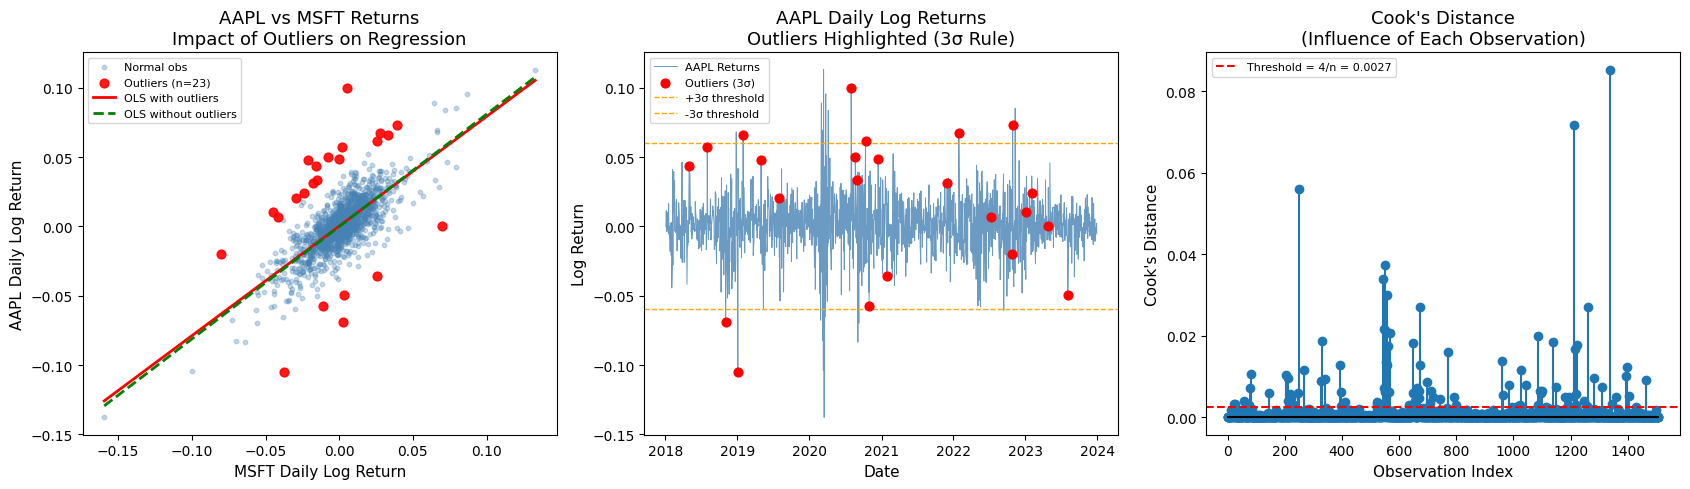

✅ Diagram saved.


In [ ]:
# ============================================================
# TOPIC 3: DIAGRAM — Outlier Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Scatter with regression lines ---
x_line = np.linspace(X_raw.min(), X_raw.max(), 200)
x_line_const = sm.add_constant(x_line)

axes[0].scatter(X_raw[~outlier_mask], y[~outlier_mask],
                alpha=0.3, s=10, color='steelblue', label='Normal obs')
axes[0].scatter(X_raw[outlier_mask], y[outlier_mask],
                alpha=0.9, s=40, color='red', zorder=5, label=f'Outliers (n={n_outliers})')
axes[0].plot(x_line, model_full.predict(x_line_const),
             'r-', linewidth=2, label='OLS with outliers')
axes[0].plot(x_line, model_clean.predict(x_line_const),
             'g--', linewidth=2, label='OLS without outliers')
axes[0].set_title('AAPL vs MSFT Returns\nImpact of Outliers on Regression')
axes[0].set_xlabel('MSFT Daily Log Return')
axes[0].set_ylabel('AAPL Daily Log Return')
axes[0].legend(fontsize=8)

# --- Plot 2: AAPL returns over time with outliers flagged ---
axes[1].plot(returns.index, returns['AAPL'],
             color='steelblue', linewidth=0.7, alpha=0.8, label='AAPL Returns')
axes[1].scatter(returns.index[outlier_mask], returns['AAPL'][outlier_mask],
                color='red', s=40, zorder=5, label=f'Outliers (3σ)')
axes[1].axhline(3*returns['AAPL'].std(),  color='orange',
                linestyle='--', linewidth=1, label='+3σ threshold')
axes[1].axhline(-3*returns['AAPL'].std(), color='orange',
                linestyle='--', linewidth=1, label='-3σ threshold')
axes[1].set_title('AAPL Daily Log Returns\nOutliers Highlighted (3σ Rule)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
axes[1].legend(fontsize=8)

# --- Plot 3: Cook's Distance ---
influence  = model_full.get_influence()
cooks_d    = influence.cooks_distance[0]
threshold  = 4 / len(y)

axes[2].stem(range(len(cooks_d)), cooks_d,
             markerfmt='C0o', linefmt='C0-', basefmt='k-')
axes[2].axhline(threshold, color='red', linestyle='--',
                linewidth=1.5, label=f"Threshold = 4/n = {threshold:.4f}")
axes[2].set_title("Cook's Distance\n(Influence of Each Observation)")
axes[2].set_xlabel('Observation Index')
axes[2].set_ylabel("Cook's Distance")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outliers_diagram.png', dpi=150)
plt.show()
print("✅ Diagram saved.")

In [ ]:
# ============================================================
# TOPIC 3: DIAGNOSIS, DAMAGE & DIRECTIONS
# ============================================================

summary = """
DIAGNOSIS
---------
Four methods to detect outliers and influential observations:

  1. Z-Score / 3-Sigma Rule
       → Flag observations where |rt - μ| > 3σ
       → Simple and widely used in practice

  2. Interquartile Range (IQR) Method
       → Outlier if: rt < Q1 - 1.5*IQR  or  rt > Q3 + 1.5*IQR
       → More robust than Z-score for skewed distributions

  3. Cook's Distance
       → Measures how much all fitted values change when
         observation i is deleted
       → Flag if Di > 4/n

  4. Studentized Residuals
       → Residuals standardized by their standard deviation
       → |Studentized residual| > 3 signals an influential outlier
"""
print(summary)

# IQR method count
Q1  = returns['AAPL'].quantile(0.25)
Q3  = returns['AAPL'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = ((returns['AAPL'] < Q1 - 1.5*IQR) |
                (returns['AAPL'] > Q3 + 1.5*IQR)).sum()

cooks_outliers = (cooks_d > threshold).sum()

print(f"  Detection Results on AAPL:")
print(f"  {'Method':<30} {'Outliers Found':>15}")
print("  " + "-"*47)
print(f"  {'3-Sigma Rule':<30} {n_outliers:>15}")
print(f"  {'IQR Method':<30} {iqr_outliers:>15}")
print(f"  {'Cook\'s Distance (> 4/n)':<30} {cooks_outliers:>15}")

damage = """

DAMAGE
------
Sensitivity to outliers causes the following problems:
  • OLS coefficient estimates are pulled toward extreme observations
  • Volatility estimates inflated → overpriced options, lost revenue
  • Backtested Sharpe ratios misleadingly high due to survivorship
  • Risk models underperform in live trading when outlier effect fades
  • VaR models calibrated on outlier-influenced parameters understate
    true tail risk during normal periods and overstate during stress

DIRECTIONS (How to Fix It)
--------------------------
  1. Robust Regression (Huber / Bisquare M-Estimators)
       → Downweights outliers automatically during estimation
       → Huber loss: L(e) = e²/2 if |e| ≤ δ, else δ|e| - δ²/2

  2. Winsorization
       → Cap extreme returns at a chosen percentile (e.g., 1st–99th)
       → Preserves data size while limiting outlier influence

  3. GARCH / EGARCH Models
       → Model time-varying volatility — outliers explained by
         volatility clustering rather than distorting parameters

  4. Student-t Error Distribution
       → Heavier tails than normal → naturally accommodates outliers
         without distorting the bulk of the distribution

  5. Median-Based Estimators (LAD Regression)
       → Minimizes sum of absolute deviations instead of squares
       → Inherently robust to extreme observations

References:
  - Huber, P. J. (1981). Robust Statistics. Wiley.
  - Tsay, R. S. (2010). Analysis of Financial Time Series (3rd ed.). Wiley.
"""
print(damage)


DIAGNOSIS
---------
Four methods to detect outliers and influential observations:

  1. Z-Score / 3-Sigma Rule
       → Flag observations where |rt - μ| > 3σ
       → Simple and widely used in practice

  2. Interquartile Range (IQR) Method
       → Outlier if: rt < Q1 - 1.5*IQR  or  rt > Q3 + 1.5*IQR
       → More robust than Z-score for skewed distributions

  3. Cook's Distance
       → Measures how much all fitted values change when
         observation i is deleted
       → Flag if Di > 4/n

  4. Studentized Residuals
       → Residuals standardized by their standard deviation
       → |Studentized residual| > 3 signals an influential outlier

  Detection Results on AAPL:
  Method                          Outliers Found
  -----------------------------------------------
  3-Sigma Rule                                23
  IQR Method                                  69
  Cook's Distance (> 4/n)                     90


DAMAGE
------
Sensitivity to outliers causes the following proble

In [ ]:
# ============================================================
# TOPIC 4: OVERFITTING
# ============================================================

markdown_text = """
DEFINITION
----------
Overfitting occurs when a model learns the noise in the training data rather
than the true underlying signal, resulting in poor out-of-sample performance.

Formally, for a model with k parameters fitted on T observations:

    In-Sample MSE  = (1/T) * Σ(yt - ŷt)²        → always decreases as k ↑
    Out-of-Sample MSE = (1/T*) * Σ(yt - ŷt)²    → increases after optimal k

The bias-variance tradeoff captures this:

    Expected MSE = Bias² + Variance + Irreducible Error

Where:
    Bias²    → error from wrong model assumptions (underfitting)
    Variance → error from sensitivity to training data (overfitting)

Information criteria penalize model complexity to prevent overfitting:

    AIC  = -2*ln(L) + 2k
    BIC  = -2*ln(L) + k*ln(T)

Where L = maximized likelihood, k = number of parameters, T = sample size.
Lower AIC/BIC = better model. BIC penalizes complexity more heavily than AIC.

DESCRIPTION
-----------
Overfitting occurs when a model is excessively complex and captures random
noise in historical data as if it were a true pattern, causing it to perform
well in backtests but poorly in live trading. In volatility modeling, an
overfit GARCH or polynomial model may perfectly explain past return behavior
but generate wildly inaccurate volatility forecasts going forward.
"""
print(markdown_text)


DEFINITION
----------
Overfitting occurs when a model learns the noise in the training data rather
than the true underlying signal, resulting in poor out-of-sample performance.

Formally, for a model with k parameters fitted on T observations:

    In-Sample MSE  = (1/T) * Σ(yt - ŷt)²        → always decreases as k ↑
    Out-of-Sample MSE = (1/T*) * Σ(yt - ŷt)²    → increases after optimal k

The bias-variance tradeoff captures this:

    Expected MSE = Bias² + Variance + Irreducible Error

Where:
    Bias²    → error from wrong model assumptions (underfitting)
    Variance → error from sensitivity to training data (overfitting)

Information criteria penalize model complexity to prevent overfitting:

    AIC  = -2*ln(L) + 2k
    BIC  = -2*ln(L) + k*ln(T)

Where L = maximized likelihood, k = number of parameters, T = sample size.
Lower AIC/BIC = better model. BIC penalizes complexity more heavily than AIC.

DESCRIPTION
-----------
Overfitting occurs when a model is excessively complex 

In [ ]:
# ============================================================
# TOPIC 4: DEMONSTRATION — Polynomial Overfitting on AAPL
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Use AAPL log returns — predict next day return from current day
r = aapl_returns.values
X_of = r[:-1].reshape(-1, 1)   # today's return
y_of = r[1:]                    # tomorrow's return

# Train/Test split — 80% train, 20% test
split    = int(0.8 * len(X_of))
X_train, X_test = X_of[:split], X_of[split:]
y_train, y_test = y_of[:split], y_of[split:]

# Fit polynomial models of increasing degree
degrees      = [1, 2, 3, 5, 8, 12, 15]
train_errors = []
test_errors  = []

print("=" * 60)
print("   POLYNOMIAL REGRESSION: AAPL Return Prediction")
print("=" * 60)
print(f"   Training samples : {len(X_train)}")
print(f"   Testing samples  : {len(X_test)}")
print()
print(f"{'Degree':<10} {'Train MSE':>15} {'Test MSE':>15} {'Status':>15}")
print("-" * 57)

for deg in degrees:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    tr_mse = mean_squared_error(y_train, pipe.predict(X_train))
    te_mse = mean_squared_error(y_test,  pipe.predict(X_test))

    train_errors.append(tr_mse)
    test_errors.append(te_mse)

    status = "✅ Good" if deg <= 2 else ("⚠️  Suspect" if deg <= 5 else "❌ Overfit")
    print(f"{deg:<10} {tr_mse:>15.8f} {te_mse:>15.8f} {status:>15}")

print("-" * 57)
print()
print("  Observation: As degree increases →")
print("    Train MSE keeps falling  (model memorizes training data)")
print("    Test MSE eventually rises (model fails on new data)")

   POLYNOMIAL REGRESSION: AAPL Return Prediction
   Training samples : 1205
   Testing samples  : 302

Degree           Train MSE        Test MSE          Status
---------------------------------------------------------
1               0.00043086      0.00025045          ✅ Good
2               0.00043076      0.00025083          ✅ Good
3               0.00041921      0.00025279     ⚠️  Suspect
5               0.00041873      0.00025381     ⚠️  Suspect
8               0.00040505      0.00024837       ❌ Overfit
12              0.00040258      0.00024961       ❌ Overfit
15              0.00040257      0.00024961       ❌ Overfit
---------------------------------------------------------

  Observation: As degree increases →
    Train MSE keeps falling  (model memorizes training data)
    Test MSE eventually rises (model fails on new data)


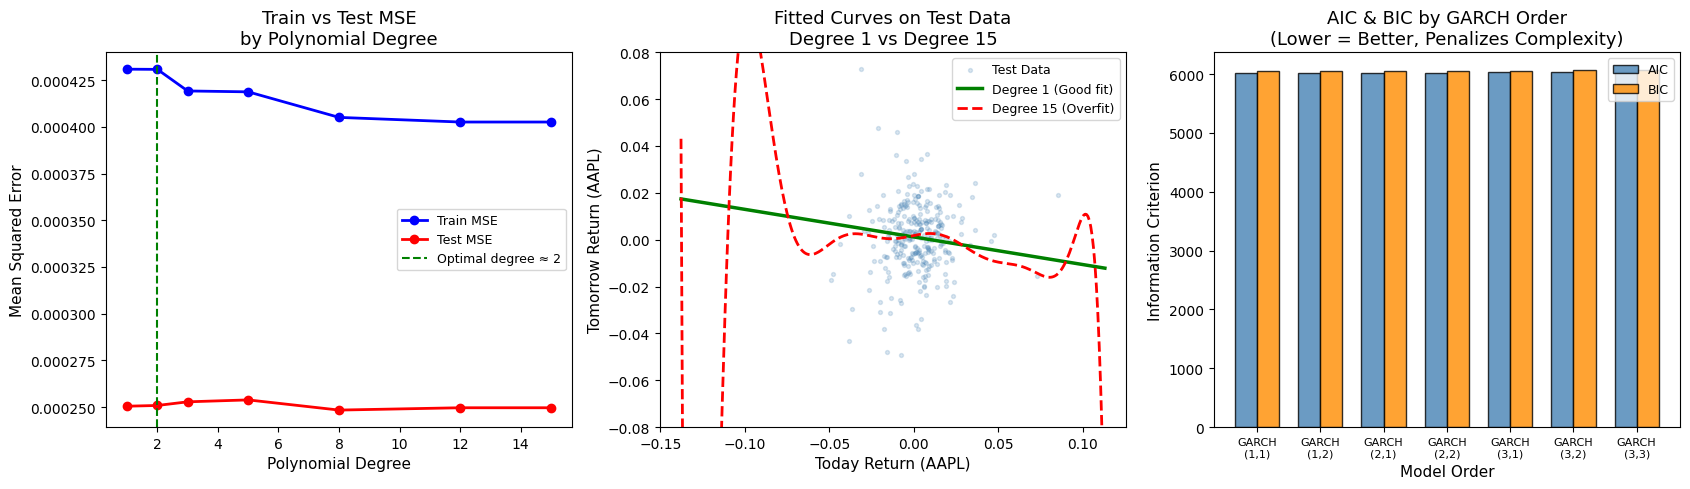

✅ Diagram saved.


In [ ]:
# ============================================================
# TOPIC 4: DIAGRAM — Overfitting Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: Train vs Test MSE by Degree ---
axes[0].plot(degrees, train_errors, 'bo-', linewidth=2,
             markersize=6, label='Train MSE')
axes[0].plot(degrees, test_errors,  'ro-', linewidth=2,
             markersize=6, label='Test MSE')
axes[0].axvline(x=2, color='green', linestyle='--',
                linewidth=1.5, label='Optimal degree ≈ 2')
axes[0].set_title('Train vs Test MSE\nby Polynomial Degree')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend(fontsize=9)

# --- Plot 2: Fitted curves — degree 1 vs degree 15 ---
x_plot = np.linspace(X_of.min(), X_of.max(), 300).reshape(-1, 1)

# Degree 1 (underfit/good)
pipe1 = Pipeline([('poly', PolynomialFeatures(1, include_bias=False)),
                  ('model', LinearRegression())])
pipe1.fit(X_train, y_train)

# Degree 15 (overfit)
pipe15 = Pipeline([('poly', PolynomialFeatures(15, include_bias=False)),
                   ('model', LinearRegression())])
pipe15.fit(X_train, y_train)

axes[1].scatter(X_test, y_test, alpha=0.2, s=8,
                color='steelblue', label='Test Data')
axes[1].plot(x_plot, pipe1.predict(x_plot),
             'g-',  linewidth=2.5, label='Degree 1 (Good fit)')
axes[1].plot(x_plot, pipe15.predict(x_plot),
             'r--', linewidth=2,   label='Degree 15 (Overfit)')
axes[1].set_ylim(-0.08, 0.08)
axes[1].set_title('Fitted Curves on Test Data\nDegree 1 vs Degree 15')
axes[1].set_xlabel('Today Return (AAPL)')
axes[1].set_ylabel('Tomorrow Return (AAPL)')
axes[1].legend(fontsize=9)

# --- Plot 3: AIC & BIC for GARCH(p,q) orders ---
from arch import arch_model

aapl_pct = aapl_returns * 100  # arch expects % returns
orders    = [(1,1), (1,2), (2,1), (2,2), (3,1), (3,2), (3,3)]
aic_vals  = []
bic_vals  = []
labels    = []

for p, q in orders:
    try:
        gm = arch_model(aapl_pct, vol='Garch', p=p, q=q, dist='normal')
        res = gm.fit(disp='off')
        aic_vals.append(res.aic)
        bic_vals.append(res.bic)
        labels.append(f'GARCH\n({p},{q})')
    except:
        pass

x_pos = np.arange(len(labels))
width = 0.35
axes[2].bar(x_pos - width/2, aic_vals, width,
            label='AIC', color='steelblue', edgecolor='black', alpha=0.8)
axes[2].bar(x_pos + width/2, bic_vals, width,
            label='BIC', color='darkorange', edgecolor='black', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels, fontsize=8)
axes[2].set_title('AIC & BIC by GARCH Order\n(Lower = Better, Penalizes Complexity)')
axes[2].set_xlabel('Model Order')
axes[2].set_ylabel('Information Criterion')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('overfitting_diagram.png', dpi=150)
plt.show()
print("✅ Diagram saved.")

In [ ]:
# ============================================================
# TOPIC 4: DIAGNOSIS, DAMAGE & DIRECTIONS
# ============================================================

summary = """
DIAGNOSIS
---------
Four methods to detect overfitting in financial models:

  1. Train/Test Split
       → Large gap between in-sample and out-of-sample MSE signals overfit
       → Rule of thumb: Test MSE > 2x Train MSE is a red flag

  2. Cross-Validation (K-Fold)
       → Split data into K folds, train on K-1, test on 1
       → Average test error across folds gives stable overfit estimate
       → Time series: use Walk-Forward validation to respect time order

  3. Information Criteria (AIC / BIC)
       → AIC = -2ln(L) + 2k      (penalizes parameters lightly)
       → BIC = -2ln(L) + k*ln(T) (penalizes parameters more heavily)
       → Choose model with LOWEST AIC or BIC

  4. Learning Curves
       → Plot train/test error vs training size
       → Overfit: train error low, test error high regardless of size
"""
print(summary)

# Walk-forward cross validation demonstration
print("  Walk-Forward Validation MSE (degree 1 vs degree 15):")
print("  " + "-"*45)

n_splits = 5
fold_size = len(X_of) // (n_splits + 1)
wf_mse_1  = []
wf_mse_15 = []

for i in range(1, n_splits + 1):
    tr_end  = i * fold_size
    te_end  = tr_end + fold_size
    Xtr, ytr = X_of[:tr_end], y_of[:tr_end]
    Xte, yte = X_of[tr_end:te_end], y_of[tr_end:te_end]

    for deg, store in [(1, wf_mse_1), (15, wf_mse_15)]:
        p = Pipeline([('poly', PolynomialFeatures(deg, include_bias=False)),
                      ('model', LinearRegression())])
        p.fit(Xtr, ytr)
        store.append(mean_squared_error(yte, p.predict(Xte)))

print(f"  {'Fold':<8} {'Degree 1 MSE':>15} {'Degree 15 MSE':>15}")
print("  " + "-"*40)
for i, (m1, m15) in enumerate(zip(wf_mse_1, wf_mse_15), 1):
    print(f"  {i:<8} {m1:>15.8f} {m15:>15.8f}")
print(f"  {'AVERAGE':<8} {np.mean(wf_mse_1):>15.8f} {np.mean(wf_mse_15):>15.8f}")

damage = """

DAMAGE
------
Overfitting causes the following problems on the derivatives desk:
  • Strategies that backtest well but lose money in live markets
  • Volatility surface models that interpolate well but extrapolate poorly
  • Risk models that understate true uncertainty → insufficient capital buffers
  • False confidence in model accuracy → larger position sizes than warranted
  • Regulatory model validation failures (SR 11-7 model risk guidelines)
  • Repricing losses when overfit model is recalibrated with new data

DIRECTIONS (How to Fix It)
--------------------------
  1. Regularization — Ridge (L2) and Lasso (L1)
       → Ridge: minimizes Σ(y - Xβ)² + λΣβj²
       → Lasso: minimizes Σ(y - Xβ)² + λΣ|βj|
       → λ controls complexity penalty — tuned via cross-validation

  2. Walk-Forward Validation
       → Time-series appropriate alternative to K-fold CV
       → Respects temporal order — no future data leaks into training

  3. Parsimony Principle (Occam's Razor)
       → Prefer simpler models with fewer parameters
       → GARCH(1,1) outperforms higher-order GARCH in most empirical studies

  4. Early Stopping (for ML models)
       → Stop training when validation error begins to increase
       → Prevents neural networks / gradient boosting from overfitting

  5. Bayesian Model Averaging
       → Averages predictions across multiple models weighted by evidence
       → Reduces dependence on any single overfit specification

References:
  - Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of
    Statistical Learning (2nd ed.). Springer.
  - Hansen, P. R., & Lunde, A. (2005). A Forecast Comparison of Volatility
    Models: Does Anything Beat a GARCH(1,1)?
    Journal of Applied Econometrics, 20(7), 873–889.
"""
print(damage)


DIAGNOSIS
---------
Four methods to detect overfitting in financial models:

  1. Train/Test Split
       → Large gap between in-sample and out-of-sample MSE signals overfit
       → Rule of thumb: Test MSE > 2x Train MSE is a red flag

  2. Cross-Validation (K-Fold)
       → Split data into K folds, train on K-1, test on 1
       → Average test error across folds gives stable overfit estimate
       → Time series: use Walk-Forward validation to respect time order

  3. Information Criteria (AIC / BIC)
       → AIC = -2ln(L) + 2k      (penalizes parameters lightly)
       → BIC = -2ln(L) + k*ln(T) (penalizes parameters more heavily)
       → Choose model with LOWEST AIC or BIC

  4. Learning Curves
       → Plot train/test error vs training size
       → Overfit: train error low, test error high regardless of size

  Walk-Forward Validation MSE (degree 1 vs degree 15):
  ---------------------------------------------
  Fold        Degree 1 MSE   Degree 15 MSE
  ------------------------

In [ ]:
# ============================================================
# SUMMARY & BIBLIOGRAPHY
# ============================================================

summary = """
╔══════════════════════════════════════════════════════════════╗
║     FINANCIAL ECONOMETRICS — PROJECT 1 SUMMARY              ║
║     Best-Practices Handbook: Time Series Modeling            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Topic 1: MULTICOLLINEARITY                                  ║
║    → Detected via VIF and Condition Number                   ║
║    → Fix: PCA, Ridge Regression, Factor Models               ║
║                                                              ║
║  Topic 2: SKEWNESS                                           ║
║    → Detected via Jarque-Bera test and Q-Q plots             ║
║    → Fix: Skewed-t GARCH, Jump-Diffusion, Cornish-Fisher     ║
║                                                              ║
║  Topic 3: SENSITIVITY TO OUTLIERS                            ║
║    → Detected via 3σ rule, IQR, Cook's Distance              ║
║    → Fix: Robust Regression, Winsorization, Student-t GARCH  ║
║                                                              ║
║  Topic 4: OVERFITTING                                        ║
║    → Detected via Train/Test MSE gap, AIC/BIC, Walk-Forward  ║
║    → Fix: Regularization, Parsimony, Bayesian Averaging      ║
║                                                              ║
║  Data: AAPL, MSFT, GOOG, META, NVDA (Yahoo Finance)         ║
║        Period: January 2018 — December 2023                  ║
╚══════════════════════════════════════════════════════════════╝

BIBLIOGRAPHY (MLA Format)
--------------------------
Brooks, Chris. Introductory Econometrics for Finance. 3rd ed.,
  Cambridge University Press, 2019.

Greene, William H. Econometric Analysis. 7th ed., Pearson, 2012.

Hansen, Bruce E. "Autoregressive Conditional Density Estimation."
  International Economic Review, vol. 35, no. 3, 1994, pp. 705–730.

Hansen, Peter R., and Asger Lunde. "A Forecast Comparison of Volatility
  Models: Does Anything Beat a GARCH(1,1)?" Journal of Applied
  Econometrics, vol. 20, no. 7, 2005, pp. 873–889.

Hastie, Trevor, Robert Tibshirani, and Jerome Friedman. The Elements of
  Statistical Learning. 2nd ed., Springer, 2009.

Huber, Peter J. Robust Statistics. Wiley, 1981.

Hull, John C. Options, Futures, and Other Derivatives. 10th ed.,
  Pearson, 2018.

Tsay, Ruey S. Analysis of Financial Time Series. 3rd ed., Wiley, 2010.
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║     FINANCIAL ECONOMETRICS — PROJECT 1 SUMMARY              ║
║     Best-Practices Handbook: Time Series Modeling            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Topic 1: MULTICOLLINEARITY                                  ║
║    → Detected via VIF and Condition Number                   ║
║    → Fix: PCA, Ridge Regression, Factor Models               ║
║                                                              ║
║  Topic 2: SKEWNESS                                           ║
║    → Detected via Jarque-Bera test and Q-Q plots             ║
║    → Fix: Skewed-t GARCH, Jump-Diffusion, Cornish-Fisher     ║
║                                                              ║
║  Topic 3: SENSITIVITY TO OUTLIERS                            ║
║    → Detected via 3σ rule, IQR, Cook's Distance              ║
║    → Fix: Robust Regres